## Task 4: Recommendation and Review Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

In [2]:
# Loading the cleaned dataset
df = pd.read_csv("../data/Amazon_Cleaned.csv")

# Removing any trailing spaces from column names
df.columns = df.columns.str.strip()

# Displaying the first five rows
df.head()
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Timestamp                              800 non-null    object
 1   age                                    800 non-null    int64 
 2   Gender                                 800 non-null    object
 3   Purchase_Frequency                     800 non-null    object
 4   Purchase_Categories                    800 non-null    object
 5   Personalized_Recommendation_Frequency  800 non-null    object
 6   Browsing_Frequency                     800 non-null    object
 7   Product_Search_Method                  800 non-null    object
 8   Search_Result_Exploration              800 non-null    object
 9   Customer_Reviews_Importance            800 non-null    int64 
 10  Add_to_Cart_Browsing                   800 non-null    object
 11  Cart_Completion_Fre

In [3]:
# Inspecting the columns 

task4_columns = [
    "Recommendation_Helpfulness",
    "Shopping_Satisfaction",
    "Review_Reliability",
    "Review_Helpfulness",
    "Personalized_Recommendation_Frequency"
]

df[task4_columns].head()

,Recommendation_Helpfulness,Shopping_Satisfaction,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency
0,Sometimes,4,Moderately,No,Yes
1,Sometimes,5,Heavily,Yes,No
2,No,3,Heavily,Sometimes,Sometimes
3,Yes,2,Occasionally,No,No
4,Yes,2,Rarely,No,Sometimes


## Relationship between Recommendation Helpfulness and Shopping Satisfaction
**Purpose:**
- Analyze whether customers who find Amazon's personalized recommendations helpful also report higher overall shopping satisfaction.

In [4]:
# Calculate average shopping satisfaction for each recommendation helpfulness response
recommendation_satisfaction = (
    df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"]
      .agg(["mean", "median", "count"])
      .sort_values(by="mean", ascending=False)
)

recommendation_satisfaction

,mean,median,count
Recommendation_Helpfulness,,,
No,3.041985,3.0,262
Yes,3.040741,3.0,270
Sometimes,2.955224,3.0,268


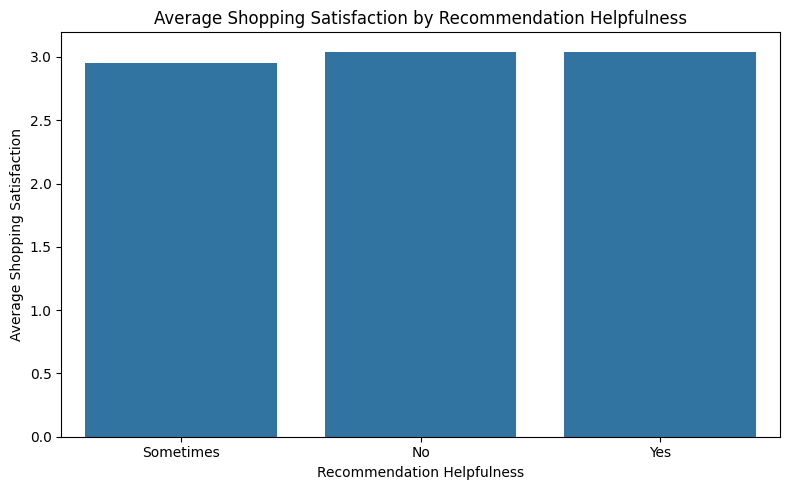

In [5]:
# Visualizing the relationship  
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Recommendation_Helpfulness",
    y="Shopping_Satisfaction",
    estimator="mean",
    errorbar=None
)

plt.title("Average Shopping Satisfaction by Recommendation Helpfulness")
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Average Shopping Satisfaction")

plt.tight_layout()
plt.show()

**Insight**
- Customers who responded "Yes" or "No" regarding recommendation helpfulness reported nearly identical average shopping satisfaction scores (approximately 3.0).
- Customers who selected "Sometimes" showed a slightly lower average satisfaction, but the difference is very small.
- Overall, the visualization suggests that perceived recommendation helpfulness alone does not have a strong influence on overall shopping satisfaction in this survey. Other factors, such as delivery experience, pricing, product quality, or review reliability, may have a greater impact on customer satisfaction.

## Statistical Relationship between Recommendation Helpfulness and Shopping Satisfaction
**Purpose:**
- Perform a Chi-Square Test of Independence to determine whether recommendation helpfulness and shopping satisfaction are statistically associated.

In [6]:
# Create a contingency table
contingency_table = pd.crosstab(
    df["Recommendation_Helpfulness"],
    df["Shopping_Satisfaction"]
)

contingency_table

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,49,52,52,57,52
Sometimes,57,55,52,51,53
Yes,46,61,56,50,57


In [7]:
#Performing the Chi-Square test

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.3f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_value:.4f}")

Chi-Square Statistic : 2.893
Degrees of Freedom   : 8
P-value              : 0.9409


In [8]:
# Interpreting the results

alpha = 0.05

if p_value < alpha:
    print("There is a statistically significant relationship between Recommendation Helpfulness and Shopping Satisfaction.")
else:
    print("There is no statistically significant relationship between Recommendation Helpfulness and Shopping Satisfaction.")

There is no statistically significant relationship between Recommendation Helpfulness and Shopping Satisfaction.


**Final Insight:**
- The average shopping satisfaction remains nearly consistent across all recommendation helpfulness groups, indicating only minor differences in customer satisfaction.
- The Chi-Square test produced a p-value of 0.9409, which is much greater than the significance level of 0.05.
- Therefore, there is no statistically significant relationship between customers' perception of recommendation helpfulness and their overall shopping satisfaction.
- This suggests that shopping satisfaction is likely influenced more by other aspects of the shopping experience, such as product quality, pricing, delivery service, or review reliability, rather than recommendation helpfulness alone.

**Business Recommendation:**
- Although personalized recommendations are an important feature of Amazon's platform, this analysis indicates that customers' overall satisfaction is not significantly affected by whether they find these recommendations helpful. 
- To improve customer satisfaction, Amazon should continue investing in core service areas such as product quality, delivery efficiency, competitive pricing, and trustworthy customer reviews while refining its recommendation engine as a complementary feature.

## Review Reliability and Helpfulness Analysis
**Purpose:** Examine whether customers who consider reviews reliable and helpful also report higher overall shopping satisfaction.

In [9]:
# Checking for unique values in the review-related columns
print("Review_Reliability:")
print(df["Review_Reliability"].unique())

print("\nReview_Helpfulness:")
print(df["Review_Helpfulness"].unique())

Review_Reliability:
['Moderately' 'Heavily' 'Occasionally' 'Rarely' 'Never']

Review_Helpfulness:
['No' 'Yes' 'Sometimes']


### Impact of Review Reliability on Shopping Satisfaction 
**Purpose:** Analyze whether customers who rely more on product reviews report higher overall shopping satisfaction.

In [10]:
# Convert Review Reliability into an ordinal numerical score

reliability_mapping = {
    "Never": 1,
    "Rarely": 2,
    "Occasionally": 3,
    "Moderately": 4,
    "Heavily": 5
}

df["Review_Reliability_Score"] = (
    df["Review_Reliability"]
    .map(reliability_mapping)
)

In [11]:
# Calculating average shopping satisfaction

review_reliability_summary = (
    df.groupby("Review_Reliability")["Shopping_Satisfaction"]
      .agg(["mean", "median", "count"])
      .reindex([
          "Never",
          "Rarely",
          "Occasionally",
          "Moderately",
          "Heavily"
      ])
)

review_reliability_summary

,mean,median,count
Review_Reliability,,,
Never,3.150602,3.0,166
Rarely,2.866667,3.0,150
Occasionally,3.037267,3.0,161
Moderately,3.076923,3.0,156
Heavily,2.922156,3.0,167


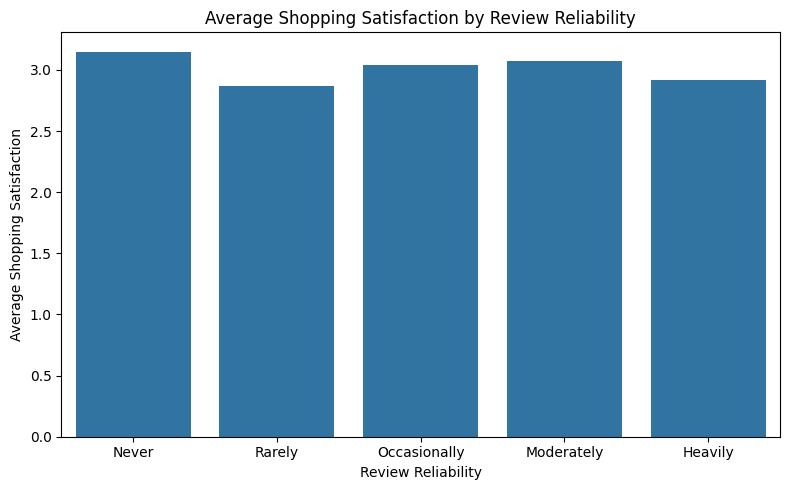

In [12]:
# Visualizing the relationship

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Review_Reliability",
    y="Shopping_Satisfaction",
    order=[
        "Never",
        "Rarely",
        "Occasionally",
        "Moderately",
        "Heavily"
    ],
    estimator="mean",
    errorbar=None
)

plt.title("Average Shopping Satisfaction by Review Reliability")
plt.xlabel("Review Reliability")
plt.ylabel("Average Shopping Satisfaction")

plt.tight_layout()
plt.show()

In [13]:
review_reliability_summary

,mean,median,count
Review_Reliability,,,
Never,3.150602,3.0,166
Rarely,2.866667,3.0,150
Occasionally,3.037267,3.0,161
Moderately,3.076923,3.0,156
Heavily,2.922156,3.0,167


**Insights:**
- The average shopping satisfaction across all review reliability groups remains close to 3.0, indicating only minor variations.
- Customers who reported Never relying on reviews had the highest average shopping satisfaction (3.15), while those who Rarely relied on reviews reported the lowest (2.87).
- No consistent upward or downward trend is observed as review reliability increases, suggesting that review reliability alone does not appear to strongly influence overall shopping satisfaction in this survey.
- These findings indicate that other aspects of the shopping experience, such as delivery performance, pricing, or product quality, are likely to have a greater impact on customer satisfaction.

In [14]:
from scipy.stats import spearmanr

# Calculate Spearman Rank Correlation
correlation, p_value = spearmanr(
    df["Review_Reliability_Score"],
    df["Shopping_Satisfaction"]
)

print(f"Spearman Correlation : {correlation:.3f}")
print(f"P-value              : {p_value:.4f}")

Spearman Correlation : -0.028
P-value              : 0.4369


In [15]:
alpha = 0.05

if p_value < alpha:
    print("There is a statistically significant relationship between Review Reliability and Shopping Satisfaction.")
else:
    print("There is no statistically significant relationship between Review Reliability and Shopping Satisfaction.")

There is no statistically significant relationship between Review Reliability and Shopping Satisfaction.


**Insight:**
- The average shopping satisfaction remained relatively consistent across all review reliability groups, with mean satisfaction scores ranging from 2.87 to 3.15.
- The Spearman correlation coefficient (-0.028) indicates an extremely weak negative relationship between review reliability and shopping satisfaction.
- The p-value (0.4369) is greater than the significance level of 0.05, indicating that the observed relationship is not statistically significant.

**Business Recommendation:**
- Since review reliability does not show a significant relationship with shopping satisfaction, Amazon should not rely solely on improving review visibility as a strategy to increase customer satisfaction.
- Customer satisfaction initiatives should prioritize broader aspects of the shopping experience, including delivery efficiency, product quality, and competitive pricing.
- Product reviews remain valuable for purchase decisions, but this analysis suggests they are not a primary driver of overall shopping satisfaction.

## Personalized Recommendation Engagement Analysis

**Purpose:** Analyze how frequently customers receive personalized recommendations and whether they perceive those recommendations as helpful.

In [16]:
# Count the frequency of personalized recommendations

recommendation_frequency = (
    df["Personalized_Recommendation_Frequency"]
    .value_counts()
)

recommendation_frequency

Personalized_Recommendation_Frequency
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64

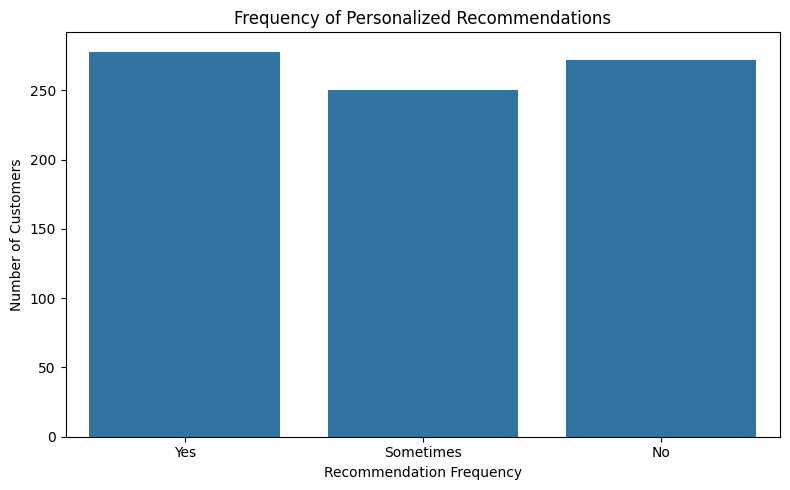

In [22]:
# Visualizing the frequency 

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Personalized_Recommendation_Frequency",
    order=["Yes", "Sometimes", "No"]
)

plt.title("Frequency of Personalized Recommendations")
plt.xlabel("Recommendation Frequency")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [19]:
# Analyzing recommendation helpfulness

recommendation_helpfulness = (
    df["Recommendation_Helpfulness"]
    .value_counts()
)

recommendation_helpfulness

Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64

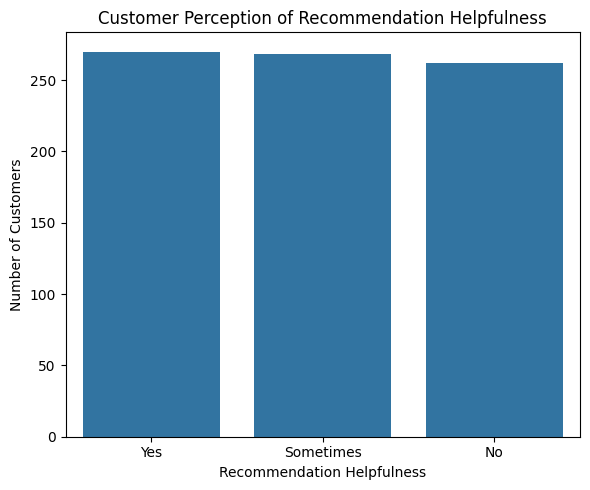

In [23]:
# Visualizing the recommendation helpfulness

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Recommendation_Helpfulness",
    order=["Yes", "Sometimes", "No"]
)

plt.title("Customer Perception of Recommendation Helpfulness")
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Insight:**
- The distribution of customers across recommendation frequency categories (Yes, No, and Sometimes) is relatively balanced, indicating that customers have varied experiences with Amazon's personalized recommendations.
- Similarly, customer opinions regarding recommendation helpfulness are evenly distributed across Yes, Sometimes, and No, with only minor differences in the number of responses.
- The absence of a dominant positive response suggests that Amazon's recommendation system delivers mixed user experiences, performing well for some customers while being less effective for others.
- These findings indicate an opportunity to improve the personalization algorithm so that recommendations become more consistently relevant across different customer groups.

**Business Recommendation:**
- Amazon should continue refining its recommendation algorithms using customer browsing history, purchase behavior, and preferences to improve recommendation relevance.
- Customers who perceive recommendations as only sometimes helpful represent a key opportunity for improvement, as increasing recommendation accuracy could encourage greater engagement and repeat purchases.
- More personalized product suggestions may improve customer engagement, even though earlier analyses showed that recommendation helpfulness alone does not significantly influence overall shopping satisfaction.